# ETF Risk Framework Visual Outputs

This notebook creates the charts and summary tables used to explain the ETF risk scores, compare ETFs and present the model results.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

risk_ranking = pd.read_csv(
    "../data/processed/etf_risk_ranking.csv"
)

scoring_data = pd.read_csv(
    "../data/processed/etf_scoring_components.csv"
)

validation_results = pd.read_csv(
    "../data/processed/out_of_sample_validation.csv",
    index_col="Ticker"
)

output_path = Path("../outputs/figures")
output_path.mkdir(parents=True, exist_ok=True)

print("Risk ranking:", risk_ranking.shape)
print("Scoring data:", scoring_data.shape)
print("Validation results:", validation_results.shape)

risk_ranking.head()

Risk ranking: (20, 11)
Scoring data: (20, 43)
Validation results: (20, 4)


,Risk_Rank,ETF_ID,ETF_Name,Ticker,Asset_Class,Market_Risk_Score,Concentration_Risk_Score,Currency_Risk_Score,Overall_Risk_Score,Risk_Band,Main_Risk_Driver
0,1,INRG,iShares Global Clean Energy Transition UCITS ETF,INRG.L,Equity,95.605031,59.391603,75,82.680499,Very High,Market risk
1,2,IUIT,iShares S&P 500 Information Technology Sector ...,IUIT.L,Equity,74.256707,84.256000,50,74.830824,High,Concentration risk
2,3,ICHN,iShares MSCI China UCITS ETF,ICHN.AS,Equity,88.438853,45.791151,75,74.300657,High,Market risk
3,4,EQQQ,Invesco EQQQ Nasdaq-100 UCITS ETF,EQQQ.L,Equity,61.709718,65.496929,50,61.674910,High,Concentration risk
4,5,SGLN,iShares Physical Gold ETC,SGLN.L,Gold,41.471987,100.000000,50,59.883192,Moderate,Concentration risk


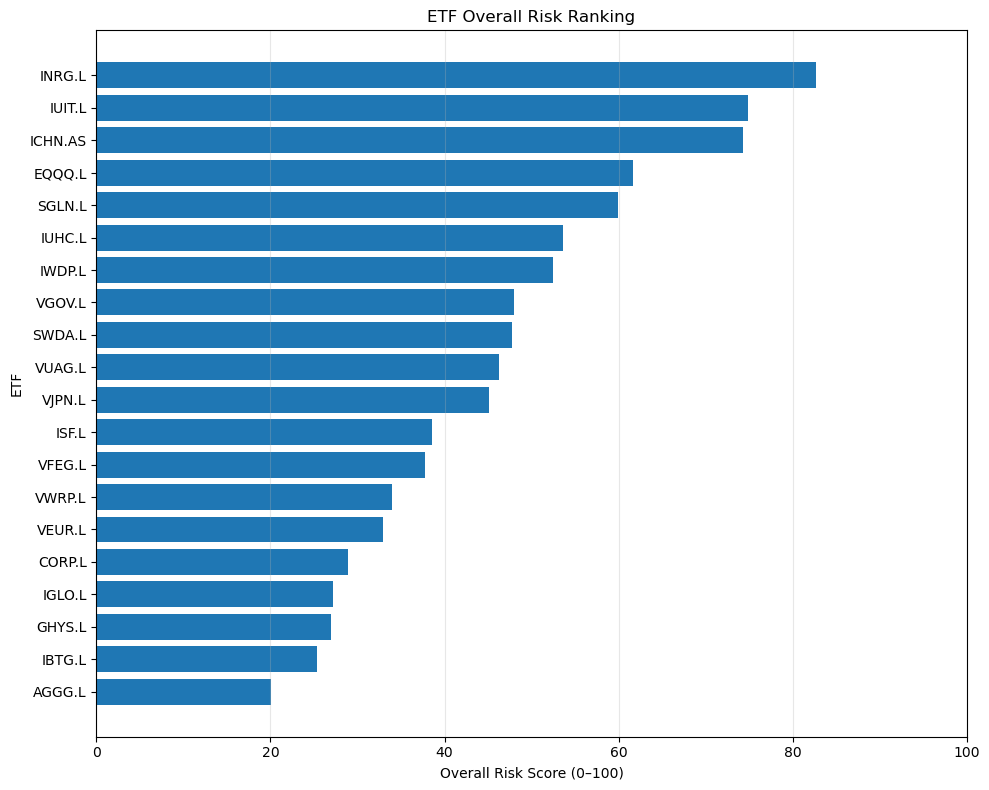

In [2]:
ranking_chart = risk_ranking.sort_values(
    "Overall_Risk_Score",
    ascending=True
)

plt.figure(figsize=(10, 8))

plt.barh(
    ranking_chart["Ticker"],
    ranking_chart["Overall_Risk_Score"]
)

plt.xlabel("Overall Risk Score (0–100)")
plt.ylabel("ETF")
plt.title("ETF Overall Risk Ranking")
plt.xlim(0, 100)
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()

plt.savefig(
    output_path / "overall_risk_ranking.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

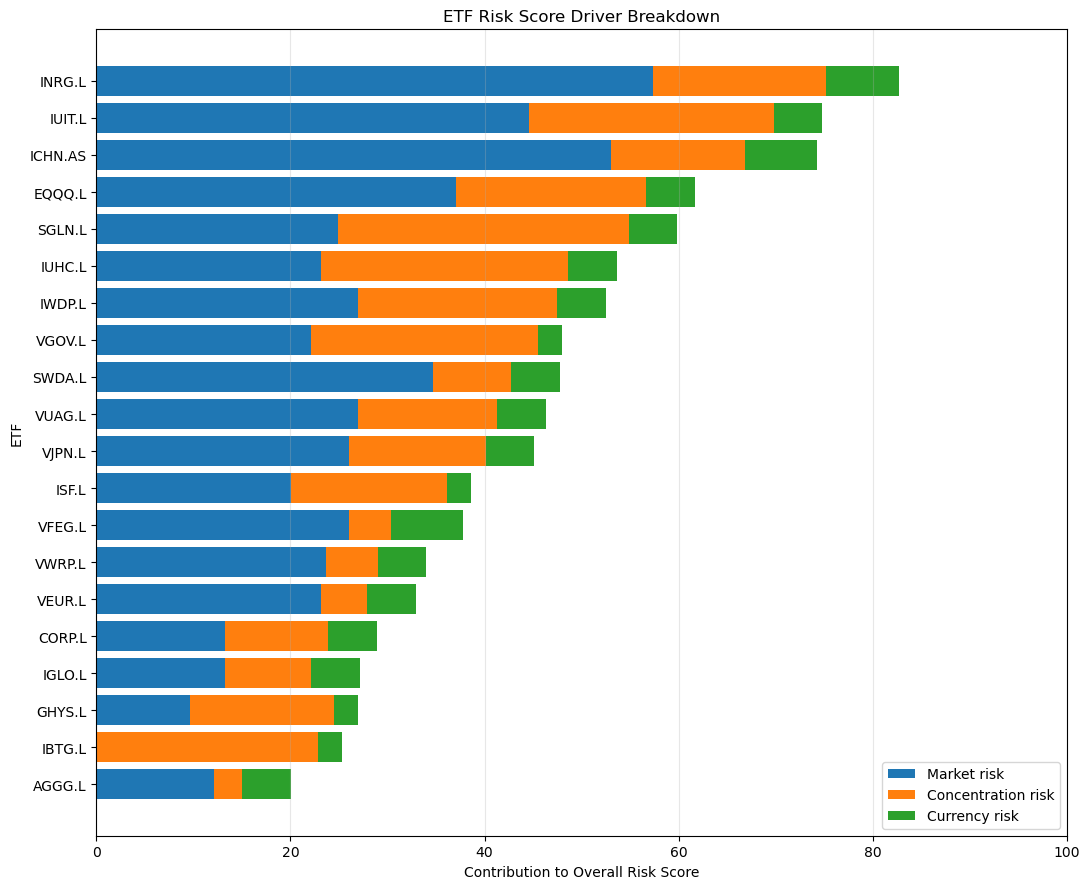

In [3]:
component_chart = scoring_data[
    [
        "Ticker",
        "Market_Risk_Score",
        "Concentration_Risk_Score",
        "Currency_Risk_Score",
        "Overall_Risk_Score"
    ]
].copy()

# Convert sub-scores into their weighted contribution
component_chart["Market_Contribution"] = (
    component_chart["Market_Risk_Score"] * 0.60
)

component_chart["Concentration_Contribution"] = (
    component_chart["Concentration_Risk_Score"] * 0.30
)

component_chart["Currency_Contribution"] = (
    component_chart["Currency_Risk_Score"] * 0.10
)

component_chart = component_chart.sort_values(
    "Overall_Risk_Score",
    ascending=True
)

plt.figure(figsize=(11, 9))

plt.barh(
    component_chart["Ticker"],
    component_chart["Market_Contribution"],
    label="Market risk"
)

plt.barh(
    component_chart["Ticker"],
    component_chart["Concentration_Contribution"],
    left=component_chart["Market_Contribution"],
    label="Concentration risk"
)

plt.barh(
    component_chart["Ticker"],
    component_chart["Currency_Contribution"],
    left=(
        component_chart["Market_Contribution"]
        + component_chart["Concentration_Contribution"]
    ),
    label="Currency risk"
)

plt.xlabel("Contribution to Overall Risk Score")
plt.ylabel("ETF")
plt.title("ETF Risk Score Driver Breakdown")
plt.xlim(0, 100)
plt.legend()
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()

plt.savefig(
    output_path / "risk_driver_breakdown.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

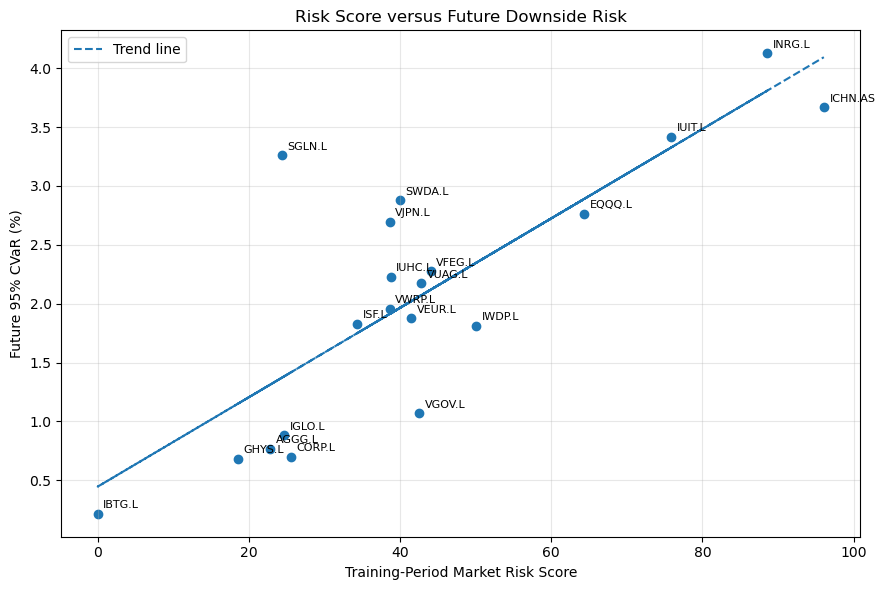

In [4]:
import numpy as np

x = validation_results["Training_Market_Risk_Score"]
y = validation_results["Testing_CVaR"] * 100

slope, intercept = np.polyfit(x, y, 1)
regression_line = slope * x + intercept

plt.figure(figsize=(9, 6))

plt.scatter(x, y)

plt.plot(
    x,
    regression_line,
    linestyle="--",
    label="Trend line"
)

for ticker in validation_results.index:
    plt.annotate(
        ticker,
        (
            validation_results.loc[ticker, "Training_Market_Risk_Score"],
            validation_results.loc[ticker, "Testing_CVaR"] * 100
        ),
        fontsize=8,
        xytext=(4, 4),
        textcoords="offset points"
    )

plt.xlabel("Training-Period Market Risk Score")
plt.ylabel("Future 95% CVaR (%)")
plt.title("Risk Score versus Future Downside Risk")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    output_path / "validation_score_vs_future_cvar.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

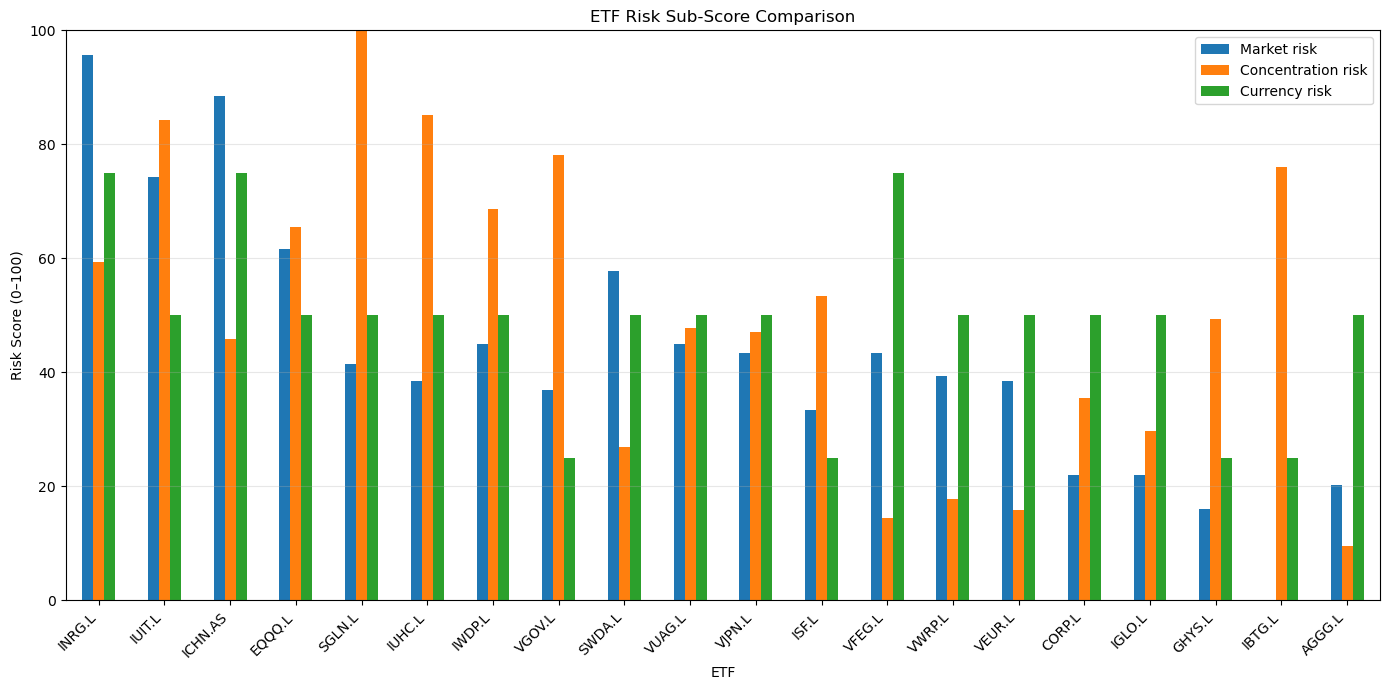

In [5]:
comparison_chart = scoring_data[
    [
        "Ticker",
        "Market_Risk_Score",
        "Concentration_Risk_Score",
        "Currency_Risk_Score"
    ]
].set_index("Ticker")

comparison_chart = comparison_chart.loc[
    risk_ranking.sort_values(
        "Overall_Risk_Score",
        ascending=False
    )["Ticker"]
]

comparison_chart.plot(
    kind="bar",
    figsize=(14, 7)
)

plt.ylabel("Risk Score (0–100)")
plt.xlabel("ETF")
plt.title("ETF Risk Sub-Score Comparison")
plt.ylim(0, 100)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.legend(
    ["Market risk", "Concentration risk", "Currency risk"]
)
plt.tight_layout()

plt.savefig(
    output_path / "risk_subscore_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()